# Movie Reviews Classification with simple RNN (Tutorial from Geek4Feek)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

In [2]:
df = pd.read_csv("../datasets/imdb.csv", names=["text", "label"])
df.head()

,text,label
0,review,sentiment
1,One of the other reviewers has mentioned that ...,positive
2,A wonderful little production. <br /><br />The...,positive
3,I thought this was a wonderful way to spend ti...,positive
4,Basically there's a family where a little boy ...,negative


In [3]:
df.shape

(50001, 2)

In [4]:
# Convert to lowercase and tokenized them => break the whole sentence into smaller unit, hold byu a Pandas Series
df['text'] = df['text'].str.lower().str.split()
df.head()

,text,label
0,[review],sentiment
1,"[one, of, the, other, reviewers, has, mentione...",positive
2,"[a, wonderful, little, production., <br, /><br...",positive
3,"[i, thought, this, was, a, wonderful, way, to,...",positive
4,"[basically, there's, a, family, where, a, litt...",negative


In [5]:
# Drop row at index 0
df = df.drop(0)

df['label'].value_counts()

label
positive    25000
negative    25000
Name: count, dtype: int64

In [6]:
# Encode label into numeric
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [7]:
df.head()

,text,label
1,"[one, of, the, other, reviewers, has, mentione...",1
2,"[a, wonderful, little, production., <br, /><br...",1
3,"[i, thought, this, was, a, wonderful, way, to,...",1
4,"[basically, there's, a, family, where, a, litt...",0
5,"[petter, mattei's, ""love, in, the, time, of, m...",1


In [8]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [9]:
# Initializing an empty set (sets automatically handle duplicates)
vocab = set()

# 1. Loop through each row in the 'text' column of the DataFrame
for phrase in df['text']:
    # 2. Each 'phrase' is a list of strings (tokens), so we loop through it
    for word in phrase:
        # 3. Add the individual word to our set
        # If the word is already there, the set just ignores the add command
        vocab.add(word)

# Result: vocab now contains every unique word found in the entire dataset

In [10]:
# Initializing an empty dictionary to store word:index pairs
word_to_idx = {}

# We use enumerate() to get both a counter (idx) and the item (word)
# We use start=1 because 0 is usually reserved for "padding" in RNNs
for idx, word in enumerate(vocab, start=1):
    # Create a dictionary entry
    # Key = the string (word), Value = the integer (idx)
    word_to_idx[word] = idx

# Result: word_to_idx looks like {'python': 1, 'machine': 2, 'learning': 3...} => the rule book for the encoding later on

In [11]:
print(len(vocab))
print(len(word_to_idx))

390931
390931


In [12]:
# Padding so that we add "0" to fill up to the max_length => we can create tensor
# Since RNN is built on matrix multiplication => need fixed size (same size for every rows)
"""
Original Sequences (Numbers from your word_to_idx):
Row 1: [1, 2, 3] (Length 3)
Row 2: [4, 5, 6, 7, 8] (Length 5)

After Padding (using max_length):
Row 1: [1, 2, 3, 0, 0] (Now length 5)
Row 2: [4, 5, 6, 7, 8] (Stays length 5)
"""
max_length = df['text'].str.len().max()

print(max_length)

def encode_and_pad(text):
    encoded = [word_to_idx[word] for word in text]
    return encoded + [0] * (max_length - len(encoded))

train_data['text'] = train_data['text'].apply(encode_and_pad)
test_data['text'] = test_data['text'].apply(encode_and_pad)

2470


In [13]:
max_length

np.int64(2470)

In [14]:
train_data

,text,label
39088,"[66461, 275560, 195107, 320391, 251882, 200069...",0
30894,"[195107, 29272, 102202, 7489, 267240, 270342, ...",0
45279,"[124011, 114991, 369698, 340638, 60390, 95648,...",1
16399,"[175284, 2573, 77604, 122701, 19456, 124011, 5...",0
13654,"[112675, 95648, 343, 195107, 338536, 274603, 1...",0
...,...,...
11285,"[168254, 268226, 355054, 267240, 147538, 36722...",1
44733,"[195107, 178395, 175284, 325576, 259965, 15834...",1
38159,"[183764, 175284, 351328, 15783, 19456, 124011,...",0
861,"[175284, 141357, 363442, 185969, 124011, 38568...",1


In [15]:
# Create Dataset and DataLoader
# The DataLoader is like a pickup truck that takes from the SentimentDataset aka the Warehouse
# with batch and shuffled to optimize memory as well as avoid data leakage (model remember the patterns)

class SentimentDataset(Dataset):
    def __init__(self, data):
        self.texts = data['text'].values
        self.labels = data['label'].values
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        return torch.tensor(text, dtype=torch.long), torch.tensor(label, dtype=torch.long)

train_dataset = SentimentDataset(train_data)
test_dataset = SentimentDataset(test_data)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [16]:
# Only use a subset of data, I can't handle this=)
from torch.utils.data import Subset

# Only take a subset = batches * size
subset_indices = list(range(1600))
train_subset = Subset(train_dataset, subset_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

In [17]:
# Defining the RNN model

class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.embedding(x)
        h0 = torch.zeros(1, x.size(0), hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

vocab_size = len(vocab) + 1
embed_size = 128
hidden_size = 128
output_size = 2 
model = SentimentRNN(vocab_size, embed_size, hidden_size, output_size)

In [18]:
# Model Training

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for i, (texts, labels) in enumerate(train_loader):
        outputs = model(texts)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()

        # Print every 10 batches so you know it's working
        if (i + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

Epoch [1/10], Batch [10/50], Loss: 0.6666
Epoch [1/10], Batch [20/50], Loss: 0.6950
Epoch [1/10], Batch [30/50], Loss: 0.6757
Epoch [1/10], Batch [40/50], Loss: 0.6961
Epoch [1/10], Batch [50/50], Loss: 0.7150
Epoch [2/10], Batch [10/50], Loss: 0.6991
Epoch [2/10], Batch [20/50], Loss: 0.7002
Epoch [2/10], Batch [30/50], Loss: 0.6922
Epoch [2/10], Batch [40/50], Loss: 0.7319
Epoch [2/10], Batch [50/50], Loss: 0.7067
Epoch [3/10], Batch [10/50], Loss: 0.6884
Epoch [3/10], Batch [20/50], Loss: 0.6910
Epoch [3/10], Batch [30/50], Loss: 0.6952
Epoch [3/10], Batch [40/50], Loss: 0.7351
Epoch [3/10], Batch [50/50], Loss: 0.6566
Epoch [4/10], Batch [10/50], Loss: 0.6879
Epoch [4/10], Batch [20/50], Loss: 0.6931
Epoch [4/10], Batch [30/50], Loss: 0.6930
Epoch [4/10], Batch [40/50], Loss: 0.6956
Epoch [4/10], Batch [50/50], Loss: 0.6975
Epoch [5/10], Batch [10/50], Loss: 0.6843
Epoch [5/10], Batch [20/50], Loss: 0.6841
Epoch [5/10], Batch [30/50], Loss: 0.6873
Epoch [5/10], Batch [40/50], Loss:

In [20]:
# Evaluation and Graph it out
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for texts, labels in test_loader:
        outputs = model(texts)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 50.39%


It's expected to be low because I set the train_loader to be very low.

Epoch [1/10], Loss: 0.6944
Epoch [2/10], Loss: 0.6934
Epoch [3/10], Loss: 0.6952
Epoch [4/10], Loss: 0.6948
Epoch [5/10], Loss: 0.6944
Epoch [6/10], Loss: 0.7008
Epoch [7/10], Loss: 0.6927
Epoch [8/10], Loss: 0.6949
Epoch [9/10], Loss: 0.6943
Epoch [10/10], Loss: 0.6934


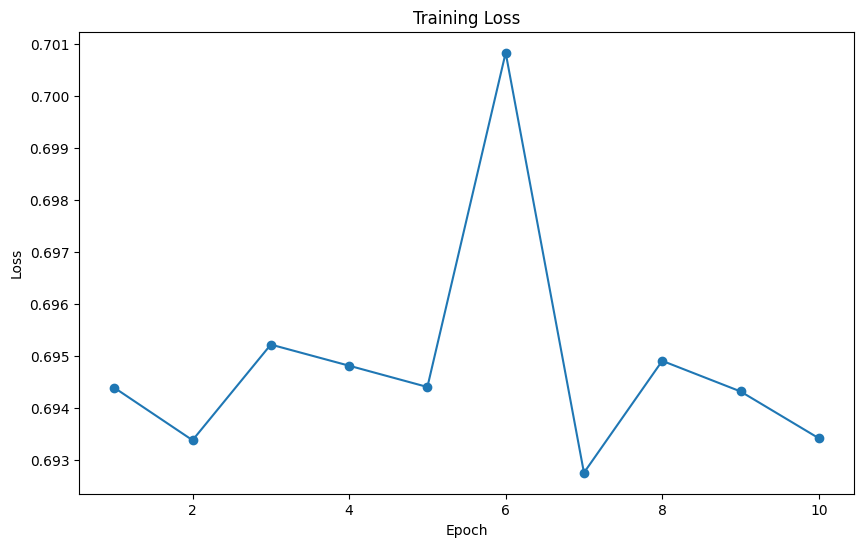

In [21]:
losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for texts, labels in train_loader:
        outputs = model(texts)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    losses.append(epoch_loss / len(train_loader))
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}')

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()